In [1]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader,Dataset
from torchvision import datasets
from torchvision.transforms import transforms
from torchvision import models
import matplotlib.pyplot as plt
import glob
import cv2
import matplotlib.pyplot as plt


# CNN on CIfar10

In [2]:
data_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

train_dataset = datasets.CIFAR10(
    root="data",
    train=True,
    transform=data_transforms,
    download = True

)

test_dataset = datasets.CIFAR10(
    root = "data",
    train = False,
    transform=data_transforms,
    download = True
)

print("Training Data Size : \n",train_dataset.data.shape)
print("Testing Data Size : \n",test_dataset.data.shape)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=True)

100%|██████████| 170M/170M [00:20<00:00, 8.38MB/s]


Training Data Size : 
 (50000, 32, 32, 3)
Testing Data Size : 
 (10000, 32, 32, 3)


In [15]:
class ConvolutionalNeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc_shape = None
    self.conv1 = nn.Sequential(
        nn.Conv2d(in_channels=3,out_channels=64,kernel_size=(3,3),padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU()
        )
    self.conv2 = nn.Sequential(
        nn.Conv2d(in_channels=64,out_channels=128,kernel_size=(3,3),padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU()
        )
    self.conv3 = nn.Sequential(
        nn.Conv2d(in_channels=128,out_channels=256,kernel_size=(3,3),padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU()
        )

    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(kernel_size=(2,2),stride=2)
    self.flatten = nn.Flatten()

    dummy_x = torch.rand(3,32,32).view(-1,3,32,32)
    self.Shape_finder(dummy_x)

    self.FC1 = nn.Linear(in_features=self.fc_shape,out_features=128)
    self.FC2 = nn.Linear(in_features=128,out_features=256)
    self.FC3 = nn.Linear(in_features=256,out_features=10)

  def Shape_finder(self,x):
    x = self.pool(self.conv1(x))
    x = self.conv2(x)
    x = self.pool((self.conv3(x)))
    self.fc_shape = x[0].shape[0] * x[0].shape[1] * x[0].shape[2]

  def forward(self,x):
    x = self.pool(self.relu(self.conv1(x)))
    x = self.conv2(x)
    x = self.pool(self.conv3(x))

    x = self.flatten(x)

    x = self.relu(self.FC1(x))
    x = self.relu(self.FC2(x))
    logits = self.FC3(x)

    return logits



In [16]:
def Train_loop(model,loss_function,optimizer,dataloader):
  train_loss = 0.0
  model.train()

  for X,y in dataloader:
    optimizer.zero_grad()
    X = X.to(device)
    y = y.to(device)
    preds = model(X)
    loss = loss_function(preds,y)

    loss.backward()
    optimizer.step()

    train_loss = train_loss + loss.item()

  return train_loss/len(dataloader)


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = ConvolutionalNeuralNetwork()
model.to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(),lr=0.001,weight_decay=0.0001)
epochs = 20

for epoch in range(epochs):
  train_loss = Train_loop(
      model = model,
      loss_function=loss_function,
      optimizer=optimizer,
      dataloader=train_loader
  )

  model.eval()
  with torch.no_grad():
    test_loss = 0.0
    correct = 0
    total = 0
    for X,y in test_loader:
      X = X.to(device)
      y = y.to(device)
      preds = model(X)
      loss = loss_function(preds,y)
      correct = correct + (preds.argmax(dim=1) == y).sum().item()
      total = total + y.size(0)
      test_loss = test_loss + loss.item()

    avg_test_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total

    print(f"Epoch : {epoch+1} | Training loss : {train_loss:.4f} | Testing loss : {avg_test_loss:.4f} | Accuracy : {accuracy} ")





Using device: cuda
Epoch : 1 | Training loss : 1.2750 | Testing loss : 0.9492 | Accuracy : 67.02 
Epoch : 2 | Training loss : 0.8824 | Testing loss : 0.8563 | Accuracy : 70.6 
Epoch : 3 | Training loss : 0.7404 | Testing loss : 0.7715 | Accuracy : 73.2 
Epoch : 4 | Training loss : 0.6263 | Testing loss : 0.7154 | Accuracy : 75.29 
Epoch : 5 | Training loss : 0.5240 | Testing loss : 0.6984 | Accuracy : 76.77 
Epoch : 6 | Training loss : 0.4351 | Testing loss : 0.6682 | Accuracy : 78.37 
Epoch : 7 | Training loss : 0.3504 | Testing loss : 0.6811 | Accuracy : 78.69 
Epoch : 8 | Training loss : 0.2865 | Testing loss : 0.7282 | Accuracy : 78.48 
Epoch : 9 | Training loss : 0.2268 | Testing loss : 0.8340 | Accuracy : 76.92 
Epoch : 10 | Training loss : 0.1797 | Testing loss : 0.8163 | Accuracy : 78.9 
Epoch : 11 | Training loss : 0.1501 | Testing loss : 0.7977 | Accuracy : 79.04 
Epoch : 12 | Training loss : 0.1213 | Testing loss : 0.9479 | Accuracy : 78.68 
Epoch : 13 | Training loss : 0.10

# Transfer Learning

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arnaudeq/cats-vs-dogs-1000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cats-vs-dogs-1000' dataset.
Path to dataset files: /kaggle/input/cats-vs-dogs-1000


In [5]:
class CustomDataLoader(Dataset):
  def __init__(self,filepath="/kaggle/input/cats-vs-dogs-1000/dogs_cats_sample_1000/dogs_cats_sample_1000/train/",transform=None):
    self.filepath = filepath
    self.transform = transform
    self.data = []
    self.filelist = glob.glob(self.filepath+"*")
    for folder in self.filelist:
      label = folder.split("/")[-1]
      for img_path in glob.glob(folder+"/*.jpg"):
        self.data.append([img_path,label])
    self.label_map = {"cats":0,"dogs":1}
    self.img_dim = (224,224)

  def __len__(self):
    return len(self.data)

  def __getitem__(self,idx):
    img_path,label = self.data[idx]
    img = cv2.imread(img_path)
    img = cv2.resize(img,self.img_dim)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img = torch.tensor(img)
    img = img.permute(2,0,1)
    if self.transform :
      img = self.transform(img)
    label = self.label_map[label]
    label = torch.tensor(label)
    return img , label

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

data_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
    ])

train_ds = CustomDataLoader(transform=data_transforms)
test_ds = CustomDataLoader("/kaggle/input/cats-vs-dogs-1000/dogs_cats_sample_1000/dogs_cats_sample_1000/valid/",transform=data_transforms)


Using device: cuda


In [7]:
train_dataloader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    test_ds,
    batch_size = 32,
    shuffle = True
)


**Plotting the data**

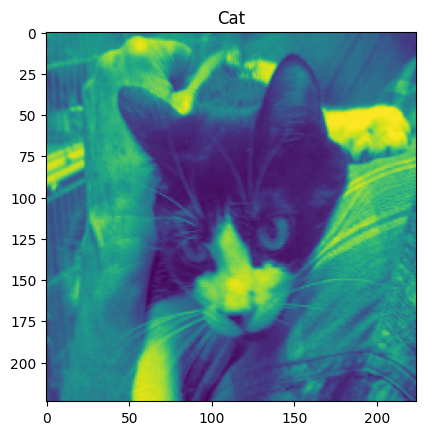

In [8]:
img , label = next(iter(train_dataloader))
plt.imshow(img[0][1].squeeze())
label_map = {0:"Cat",1:"Dog"}
plt.title(label_map[label[0].item()])
plt.show()

In [11]:
def train_model(model,optimizer,loss_function,dataloader):
  model.train()
  train_loss = 0.0
  correct = 0
  total = 0

  for X,y in dataloader:
    optimizer.zero_grad()
    X = X.to(device)
    y = y.to(device)

    preds = model(X)
    loss = loss_function(preds,y)

    loss.backward()
    optimizer.step()

    predicted = preds.argmax(dim=1)
    correct = correct + (predicted==y).sum().item()
    total = total + y.size(0)
    train_loss = train_loss + loss.item()

  accuracy = correct * 100 / total
  avg_train_loss = train_loss / len(dataloader)

  return avg_train_loss,accuracy

In [15]:
model = models.resnet50(weights="IMAGENET1K_V2")
num_features = model.fc.in_features

model.fc = nn.Linear(num_features,2)
model.to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.0001)
Epochs = 10

for epoch in range(Epochs):
  train_loss , train_acc = train_model(
      model = model,
      optimizer = optimizer,
      loss_function = loss_function,
      dataloader = train_dataloader
  )

  model.eval()
  with torch.no_grad():
    test_loss = 0.0
    correct = 0
    total = 0
    for X,y in test_dataloader:
      X = X.to(device)
      y = y.to(device)

      preds = model(X)
      loss = loss_function(preds,y)

      predicted = preds.argmax(dim=1)
      test_loss = test_loss + loss.item()
      correct = correct + (predicted == y).sum().item()
      total = total + y.size(0)
    avg_test_loss = test_loss / len(test_dataloader)
    test_accuracy = correct * 100 / total
    print(f"Epoch : {epoch+1} | Train loss : {train_loss} | Train Accuracy : {train_acc} | Test loss : {avg_test_loss} | Test Accuracy : {test_accuracy}")

Epoch : 1 | Train loss : 0.19144996445596454 | Train Accuracy : 94.4 | Test loss : 0.04810827472321098 | Test Accuracy : 98.4
Epoch : 2 | Train loss : 0.022958582536953074 | Train Accuracy : 99.4 | Test loss : 0.05184556631415728 | Test Accuracy : 98.45
Epoch : 3 | Train loss : 0.008975452936572275 | Train Accuracy : 99.85 | Test loss : 0.046812640421742956 | Test Accuracy : 98.55
Epoch : 4 | Train loss : 0.003785207330356426 | Train Accuracy : 99.95 | Test loss : 0.038844837613093354 | Test Accuracy : 98.7
Epoch : 5 | Train loss : 0.006752336266106882 | Train Accuracy : 99.85 | Test loss : 0.035779635559828465 | Test Accuracy : 98.7
Epoch : 6 | Train loss : 0.0028487464077197873 | Train Accuracy : 99.95 | Test loss : 0.07509320988601613 | Test Accuracy : 97.8
Epoch : 7 | Train loss : 0.0017638311514423953 | Train Accuracy : 100.0 | Test loss : 0.05760363725661707 | Test Accuracy : 98.35
Epoch : 8 | Train loss : 0.00035396309907636826 | Train Accuracy : 100.0 | Test loss : 0.0442925137